In [1]:
#generate wake-like spike patterns and obtain p-value  FigS20

import os
import sys
import matplotlib.pyplot as plt
from scipy import integrate
import traceback
from tqdm import tqdm
import math
from scipy.signal import find_peaks
from scipy.signal import periodogram
from scipy import signal
import scipy

import pickle


from collections import deque
import itertools
import numpy as np
import pandas as pd

fs = 20
fs_l = 15

In [2]:
import os
import sys

sys.path.append('../')
sys.path.append('../anmodel')
import matplotlib.pyplot as plt

import anmodel

import pickle


OK
OK


In [3]:
a_ISI_w = 0.03 #-0.15
b_ISI_w  = 0.65  #1.0

ISI_lim_w=-b_ISI_w/a_ISI_w
ISI_lim_w


a_IBI, b_IBI = 0.3, -0.50 
a_dur, b_dur = 0.3, - 0.5
a_ISI, b_ISI = -0.25, 1.0
a_updn, b_updn = -0.60, 4.0

IBI_lim = -b_IBI /a_IBI
dur_lim = -b_dur/a_dur
ISI_lim = -b_ISI/a_ISI 

IBI_lim2 = -(b_dur/a_dur)*a_updn + b_updn
# dur_M = (IBI_M-b_updn)/a_updn
# dur_SD = a_dur*dur_M + b_dur

print("IBI_lim > ", IBI_lim)
print("IBI_lim2 < ", IBI_lim2)

print("dur_lim > ", dur_lim)
print("ISI_lim <", ISI_lim)
print("ISI_lim_w <", ISI_lim_w)

IBI_lim >  1.6666666666666667
IBI_lim2 <  3.0
dur_lim >  1.6666666666666667
ISI_lim < 4.0
ISI_lim_w < -21.666666666666668


In [5]:

def gen_spikes_wake(N, T, dt, M, seed=False):
  Lts = int(T/dt)

  SD = a_ISI_w * M + b_ISI_w 

  poisson_trains = np.zeros((N,Lts)) 
  
  for i in range(N):
      t=0
      while (t < Lts):
         t += (10**(np.random.normal(M, SD, 1)[0]))/dt #ms
         if t <Lts:
             poisson_trains[i][math.floor(t)] = 1

  return poisson_trains



def CC_network(sp_np,  T, dt, w):
    Lt = int(T/dt)
    N=len(sp_np)
    sp_fre_li = np.sum(sp_np, axis=1)
    sp_fre_nonzero = [item for item in sp_fre_li if item != 0]
    fre_pro = math.prod(sp_fre_nonzero)
    CC_li = []
    for m in range(N):
        sps_ref = sp_np[m]
        CC_sum_n =0
        for k, j in enumerate(sps_ref):
            if j ==1:
                if k-w/dt >=0 and k+w/dt < T/dt:
                    CC_sum_n += np.sum(sp_np[:, int(k-w/dt):int(k+w/dt)])
    #               print(np.sum(spts[:, int(k-w/dt):int(k+w/dt)]))
        CC_li.append(CC_sum_n/(((fre_pro)**(1/N)))/N)  #*np.mean(sp_fre_li)
#         print("CC_sum_n", CC_sum_n)
    CC = np.mean(CC_li)
#     print("CC_mean", CC)
    return CC

def sp_cv(spts, T, dt, w, moving):
    N = spts.shape[0]
    wc = int((T-w)/moving+1)
    sp_li = []
    for m in range(wc):
        sp_sum = np.sum(spts[:,int(m*moving/dt):int(m*moving/dt + w/dt)])
        sp_li.append(sp_sum)
    if np.mean(sp_li)!=0:
        sps_cv = (np.std(sp_li)/np.mean(sp_li)).astype("float32")
    else:
        sps_cv =0
#     print("CV_sp_count/w", sps_cv)
    return sps_cv







def spike_search_w(N, T, dt, fr_i, lim_li, ini,  step, lr, seed):
    Lt = int((T)/dt) #0.1ms
    lim = [i/10 for i in lim_li]
    rate_li = []
    param_li=[]
    spikes_li = []

    pc=0
    mc=0
    param = ini

    for n,fr in enumerate(fr_li):
        print("search:{} Hz".format(fr))

        ISI_lim_w=-b_ISI_w/a_ISI_w
        while(1):
            print("param", param)
            if param>ISI_lim_w:
               param -= step*lr
               step = step*lr

            else:
                spikes = gen_spikes_wake(N, (T),dt, param, seed)
                av_rate = np.mean(np.sum(spikes, axis = 1)/((T)/1000))  #averaged rate

                print("averaged rate", round(av_rate,4))
                if av_rate >=fr - lim[n] and av_rate <fr + lim[n]:
                    param_li.append(param)
                    rate_li.append(av_rate)
                    spikes_li.append(spikes)
                    break
                elif av_rate < fr + lim[n]:
                    param -= step
                    mc+=1
                else:
                    param += step
                    pc+=1
                if mc>=2 and pc>=2:
                    step = step*lr
                    print("step", step)
                    mc=0
                    pc=0
                elif mc>5 or pc >5:
                    step = step*(1+(1-lr))
                    print("step", step)
                    mc=0
                    pc=0

        #     rate_li.append(av_rate)
    param_li=[round(i,4) for i in param_li]
    print(param_li)
    print(rate_li)
    return spikes_li, param_li

def random_samp(relm):
    x=np.random.rand(1)*(relm[1]-relm[0])+relm[0]
    return x[0]


def read_cv_dis(dst,N,T,dt,ISI_M_r,  counts):
    p=os.getcwd() #"/mnt/SSD1/net_search/anmodel"
    for i in range(counts):
        cv_dis=np.load(dst+"/CV_random_dis/ISIr_{}_{}/N{}_T{}_dt{}/CV_w_{}.npy".format(ISI_M_r[0],ISI_M_r[1],N,T,dt,i)).astype('float32')
        if i==0:
            cv_dis_all = cv_dis
        else:
            cv_dis_all = np.concatenate([cv_dis_all, cv_dis]).astype('float32')
    
    cv_dis_all = np.array(sorted(cv_dis_all))  # small-> large
    return cv_dis_all

def get_cv_pv(cv, cv_dis):
    minx = np.argmin(np.abs(cv_dis-cv))

#     low_p = minx/len(cv_dis)*100
    up_p = (len(cv_dis)-minx)/len(cv_dis)*100
    
    pv=up_p


    return pv


#generate wake-like firing patterns
def sp_random_multi(savedir, ISI_M_r, c, N,T, dt, wcv, moving, i_c):
    CV_li = []
    rate_li=[]

    for i in range(c):

        ISI_M =random_samp(ISI_M_r)
        if ISI_M > 6.5:
            continue
        seed=5
        spikes = gen_spikes_wake(N, T,dt, ISI_M, seed)
        av_rate = round(np.mean(np.sum(spikes, axis = 1)/((T)/1000)), 10)  #averaged rate
 
        rate_li.append(av_rate)
        CV_w = sp_cv(spikes, T, dt, wcv, moving)

        CV_li.append(CV_w)
    print("mean_CV", np.mean(CV_li))
    print("max_CV", np.max(CV_li))

       
    np.save(savedir+"CV_w_{}".format(i_c), np.array(CV_li))
#     print("save CV_w_{}".format(i_c))
    

    
    

In [7]:
#generate random wake-like spikes and calculate Coeffient of variance(CV)

from multiprocessing import Process
import multiprocessing


N= 80  #80  160  #320  #1000
T = 5000  #ms #2500, 5000, 10000
dt = 0.01

ISI_M_r = [1.3, 3.0]  # range of log10(mean of Inter-spike Interval) #[1.0, 4.0] #30HZ - 0.1Hz     [1.5, 2.6]  10Hz - 1.0Hz,    [1.3,3.0] 15Hz - 0.5Hz

wcv = 50 #ms
moving = 50 #ms

c=10000 #numbers of spike patterns per unit
cores = 4
repeat = 25  #total spike patterns = cores * repeat * c

offset=0  #start count


rdir="../AN_network/"
savedir = rdir + "CV_random_dis/ISIr_{}_{}/N{}_T{}_dt{}/".format(ISI_M_r[0],ISI_M_r[1],N,T,dt)
try:
    os.makedirs(savedir)
except FileExistsError:
    print("{} is already exist".format(savedir))  

    
for re in range(repeat):
    jobs=[]
    for i in range(cores):
        np.random.seed()

        i_c=offset+i+(re*cores)
        print("i_c: ", i_c)
        pro= Process(target=sp_random_multi, args=(savedir, ISI_M_r, c, N,T, dt, wcv, moving, i_c))
         
        pro.start()
        jobs.append(pro)

    for job in jobs:
        job.join()
    

i_c:  0
i_c:  1
i_c:  2
i_c:  3
mean_CV 0.30424294
max_CV 0.56904703
mean_CV 0.30305338
max_CV 0.55624646
mean_CV 0.3013032
max_CV 0.55074203
mean_CV 0.3030425
max_CV 0.56020343
i_c:  4
i_c:  5
i_c:  6
i_c:  7
mean_CV 0.30277264
max_CV 0.5638386
mean_CV 0.30368543
max_CV 0.58738613
mean_CV 0.30197427
max_CV 0.55492806
mean_CV 0.30247638
max_CV 0.5530852
i_c:  8
i_c:  9
i_c:  10
i_c:  11
mean_CV 0.30276427
max_CV 0.5653576
mean_CV 0.30221212
max_CV 0.55445874
mean_CV 0.30363223
max_CV 0.5811379
mean_CV 0.30094507
max_CV 0.5751062
i_c:  12
i_c:  13
i_c:  14
i_c:  15
mean_CV 0.30306748
max_CV 0.552811
mean_CV 0.30415916
max_CV 0.5565609
mean_CV 0.3039912
max_CV 0.5696773
mean_CV 0.30249918
max_CV 0.5886229
i_c:  16
i_c:  17
i_c:  18
i_c:  19
mean_CV 0.30311942
max_CV 0.5741767
mean_CV 0.30405357
max_CV 0.5602087
mean_CV 0.30321252
max_CV 0.5789012
mean_CV 0.3019692
max_CV 0.5770274
i_c:  20
i_c:  21
i_c:  22
i_c:  23
mean_CV 0.3035175
max_CV 0.584075
mean_CV 0.30321905
max_CV 0.58012915
m

[0.14662717 0.15072449 0.15544441 ... 1.0628663  1.0871202  1.1112825 ]
cv_max 1.1112825
p 9.999999999999999e-05


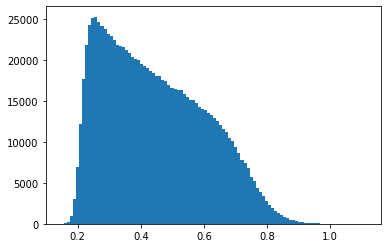

In [9]:
#histgram for CV of generated spike samples
#get p-value from cv value

N=80
T=5000
dt = 0.01
ISI_M_r = [1.3, 3.0]  #[1.0, 4.0] #30HZ - 0.1Hz     [1.5, 2.6]  10Hz - 1.0Hz,    [1.3,3.0] 15Hz - 0.5Hz
bins=100


counts = 100  # total samples = counts * c(10000)
cv=1.0
cv_dis=read_cv_dis(rdir, N, T, dt, ISI_M_r, counts)
print(cv_dis)
print("cv_max", np.max(cv_dis))
plt.hist(cv_dis, bins=bins)
pv=get_cv_pv(cv, cv_dis)
print("p", pv)


plt.figure(figsize=(6,6))
plt.hist(cv_dis, bins=bins, color="skyblue")

plt.xlabel('CV',fontsize = fs)
plt.ylabel("Counts", fontsize = fs)    
# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
plt.savefig("{}_{}_his.SVG".format(NE, NI, con_M, con_ex_ex, con_M_in, con_in_in))
plt.show()


cv_max 1.1112825


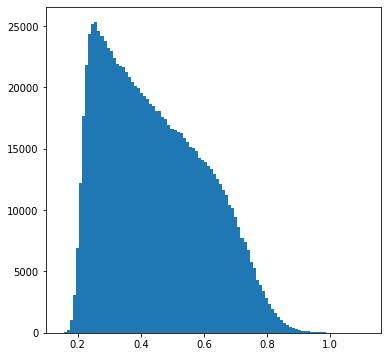

p<0.01 cv=1.0000000000000002
p>=0.01 cv=0.9000000000000001
p 0.0031999999999999997


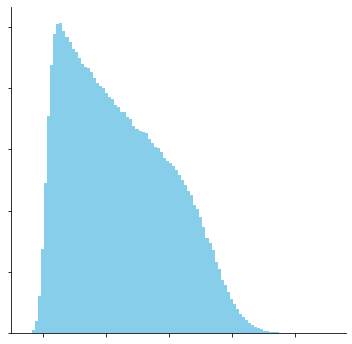

In [10]:

#calc cv from p-value

p_th = 0.01
cv_r = np.arange(0.2, 5, 0.1)  #range of CV
N=80
T=5000
dt = 0.01
ISI_M_r =  [1.3, 3.0]  #[1.0, 4.0] #30HZ - 0.1Hz     [1.5, 2.6]  10Hz - 1.0Hz,    [1.3,3.0] 15Hz - 0.5Hz
counts = 100
bins=100

cv_dis=read_cv_dis(rdir, N, T, dt, ISI_M_r, counts)
# print(cv_dis)
print("cv_max", np.max(cv_dis))
plt.figure(figsize=(6,6))
plt.hist(cv_dis,bins=bins)
plt.show()

for n,cv in enumerate(cv_r):
    pv=get_cv_pv(cv, cv_dis)
    
    if pv < p_th:
        print("p<{} cv={}".format(p_th,cv))
        print("p>={} cv={}".format(p_th,cv_pre))
        print("p", pv)
        break
    else:
        cv_pre = cv
        
        
plt.figure(figsize=(6,6))
plt.hist(cv_dis, bins=bins, color="skyblue")
# plt.xlim(0,20)
# plt.ylim(0,35)
plt.xlabel('',fontsize = fs)
plt.ylabel("", fontsize = fs)    

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

plt.savefig("CV_dis_N{}_T{}_dt{}_{}-{}.SVG".format(N, T, dt, ISI_M_r[0],ISI_M_r[1]))
plt.show()

In [24]:
#check firing rate by ISIM

N=80

T = 5000 #ms
dt = 0.01
offset = 0
Lt = int((T +offset)/dt) #0.1ms
  
param =2.6  #ISIM

spikes = gen_spikes_wake(N, T, dt, param, seed=0)
   
    

av_rate = round(np.mean(np.sum(spikes, axis = 1)/((T+offset)/1000)), 3)
print("averaged rate: {}".format(av_rate))

averaged rate: 1.125


cv_max 1.1456538
p<0.01 cv=1.0000000000000002
p>=0.01 cv=0.9000000000000001
p 0.0019000000000000002
cv_max 1.1112825
p<0.01 cv=1.0000000000000002
p>=0.01 cv=0.9000000000000001
p 0.0031999999999999997
cv_max 1.074464
p<0.01 cv=1.0000000000000002
p>=0.01 cv=0.9000000000000001
p 0.009000000000000001


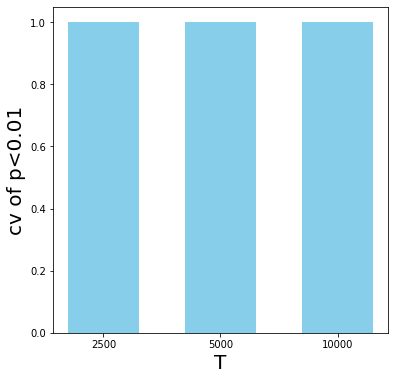

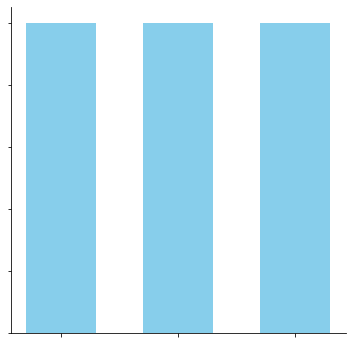

In [12]:
# CV with p_value=0.01 in different observation time 
p_th = 0.01
cv_r = np.arange(0.2, 5, 0.1)
N=80
Ts=[2500, 5000, 10000]
Ts_st=["2500", "5000", "10000"]
dt = 0.01
ISI_M_r =  [1.3, 3.0]  #[1.0, 4.0]
counts = 100
bins=100


cv_p_li=[]
for T in Ts:
    cv_dis=read_cv_dis(rdir, N, T, dt, ISI_M_r, counts)
# print(cv_dis)
    print("cv_max", np.max(cv_dis))


    for n,cv in enumerate(cv_r):
        pv=get_cv_pv(cv, cv_dis)

        if pv < p_th:
            print("p<{} cv={}".format(p_th,cv))
            print("p>={} cv={}".format(p_th,cv_pre))
            print("p", pv)
            break
        else:
            cv_pre = cv
    cv_p_li.append(cv)




plt.figure(figsize=(6,6))
plt.bar(Ts_st, cv_p_li, color="skyblue",width = 0.6)
plt.xlabel('T',fontsize = fs)
plt.ylabel("cv of p<0.01", fontsize = fs)    

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

plt.savefig("CV_dis_N{}_dt{}_{}-{}_Ts.SVG".format(N, dt, ISI_M_r[0],ISI_M_r[1]))
plt.show()

cv_max 0.85033214
p<0.01 cv=0.8000000000000003
p>=0.01 cv=0.7000000000000002
p 0.0009
cv_max 1.1112825
p<0.01 cv=1.0000000000000002
p>=0.01 cv=0.9000000000000001
p 0.0031999999999999997
cv_max 2.652026
p<0.01 cv=2.3000000000000007
p>=0.01 cv=2.200000000000001
p 0.0063


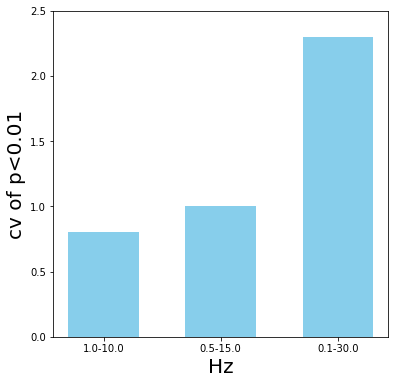

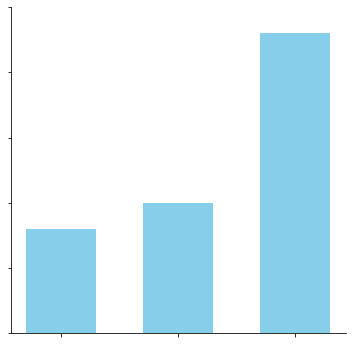

In [22]:
# CV with p_value=0.01 in different range of firing rates
p_th = 0.01
cv_r = np.arange(0.2, 5, 0.1)
N=80
T=5000


Hz_li=["1.0-10.0", "0.5-15.0", "0.1-30.0"]
dt = 0.01
ISI_M_rs =  [[1.5, 2.6], [1.3, 3.0], [1.0, 4.0]]  #[1.0, 4.0]   #[1.0, 4.0] #30HZ^ 0.1Hz     [1.5, 2.6]  10~1.0Hz,
counts = 100
bins=100


cv_p_li=[]
for ISI_M_r in ISI_M_rs:
    cv_dis=read_cv_dis(rdir, N, T, dt, ISI_M_r, counts)
# print(cv_dis)
    print("cv_max", np.max(cv_dis))
# plt.figure(figsize=(6,6))
# plt.hist(cv_dis,bins=bins)
# plt.show()

    for n,cv in enumerate(cv_r):
        pv=get_cv_pv(cv, cv_dis)

        if pv < p_th:
            print("p<{} cv={}".format(p_th,cv))
            print("p>={} cv={}".format(p_th,cv_pre))
            print("p", pv)
            break
        else:
            cv_pre = cv
    cv_p_li.append(cv)




plt.figure(figsize=(6,6))

plt.bar(Hz_li, cv_p_li, color="skyblue",width = 0.6)
plt.xlabel('Hz',fontsize = fs)
plt.ylabel("cv of p<0.01", fontsize = fs)    
plt.ylim(0,2.5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

plt.savefig("CV_dis_N{}_T{}_dt{}_ISIrs.SVG".format(N, T, dt))
plt.show()

cv_max 1.1112825
p<0.01 cv=1.0000000000000002
p>=0.01 cv=0.9000000000000001
p 0.0031999999999999997
cv_max 0.7880094
p<0.01 cv=0.8000000000000003
p>=0.01 cv=0.7000000000000002
p 9.999999999999999e-05
cv_max 0.6165917
p<0.01 cv=0.6000000000000001
p>=0.01 cv=0.5000000000000001
p 0.00019999999999999998


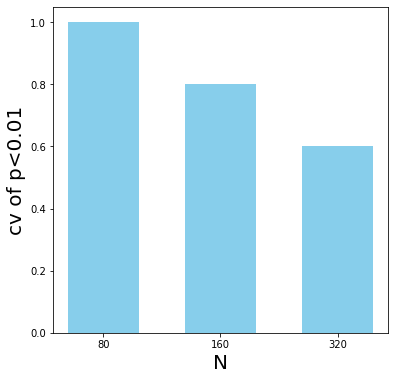

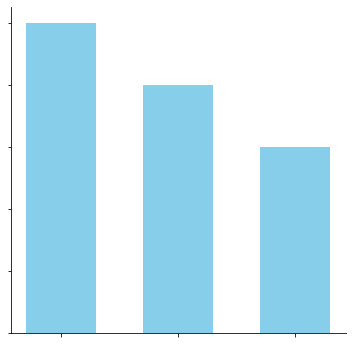

In [21]:
# CV with p_value=0.01 in different number of neurons in network
p_th = 0.01
cv_r = np.arange(0.2, 5, 0.1)
Ns=[80, 160, 320]
N_li=["80", "160", "320"]
T=5000


dt = 0.01
ISI_M_r =  [1.3, 3.0]  #[1.0, 4.0]   #[1.0, 4.0] #30HZ^ 0.1Hz     [1.5, 2.6]  10~1.0Hz,

counts = 100
bins=100


cv_p_li=[]
for N in Ns:
    cv_dis=read_cv_dis(rdir, N, T, dt, ISI_M_r, counts)
# print(cv_dis)
    print("cv_max", np.max(cv_dis))


    for n,cv in enumerate(cv_r):
        pv=get_cv_pv(cv, cv_dis)

        if pv < p_th:
            print("p<{} cv={}".format(p_th,cv))
            print("p>={} cv={}".format(p_th,cv_pre))
            print("p", pv)
            break
        else:
            cv_pre = cv
    cv_p_li.append(cv)




plt.figure(figsize=(6,6))

plt.bar(N_li, cv_p_li, color="skyblue",width = 0.6)
plt.xlabel('N',fontsize = fs)
plt.ylabel("cv of p<0.01", fontsize = fs)    

# plt.ylim(0,2.5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

plt.savefig("CV_dis_T{}_dt{}_{}-{}_Ns.SVG".format(T, dt,ISI_M_r[0],ISI_M_r[1]))
plt.show()